# Spectral visualizations

Compute compact Welch, Morlet, phase, connectivity, and cross-frequency examples with explicit bands and windows.

All signals, labels, and coordinates in this notebook are deterministic and
synthetic. They do not represent a participant. Run cells from top to bottom.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Allow this notebook to run from JupyterLab or from the repository root.
HERE = Path.cwd()
EXAMPLES = HERE if (HERE / "_synthetic.py").exists() else HERE / "notebooks" / "examples"
sys.path.insert(0, str(EXAMPLES.resolve()))
REPOSITORY = EXAMPLES.parents[1]
if (REPOSITORY / "ERPy").exists():
    sys.path.insert(0, str(REPOSITORY.resolve()))

import ERPy as ep
import ERPy.viz as viz
from IPython.display import Image, display as show_output
from _synthetic import (
    make_detection_table,
    make_edges,
    make_electrode_metadata,
    make_epochs,
    make_metric_table,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

# The publication workflow stores PNGs so the figures render directly on GitHub.
get_ipython().run_line_magic("matplotlib", "inline")

def show_plotly_snapshot(figure):
    # Use figure.show() to interact locally; these PNGs also render on GitHub.
    import plotly.graph_objects as go
    preview = go.Figure(figure)
    preview.layout.sliders = ()
    preview.layout.updatemenus = ()
    preview.update_layout(
        legend={"orientation": "h", "y": -0.08, "x": 0.05},
        margin={"l": 30, "r": 100, "t": 65, "b": 70},
    )
    show_output(Image(preview.to_image(format="png", width=1000, height=650, scale=1)))

In [2]:
epochs = make_epochs(n_trials=12, sfreq=500.0)
config = ep.SpectralConfig(
    fmin=4.0, fmax=80.0, n_freqs=18, n_cycles=5.0,
    baseline=(-0.4, -0.05), baseline_mode="logratio", decim=4,
)

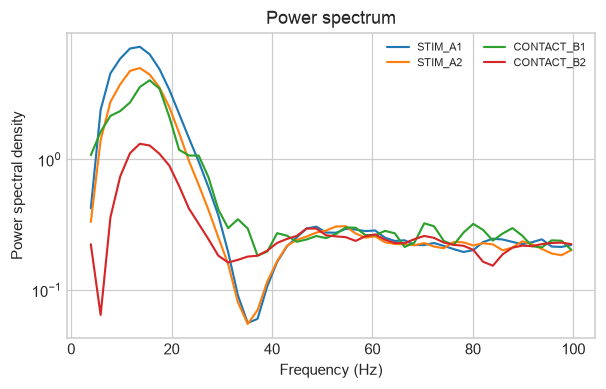

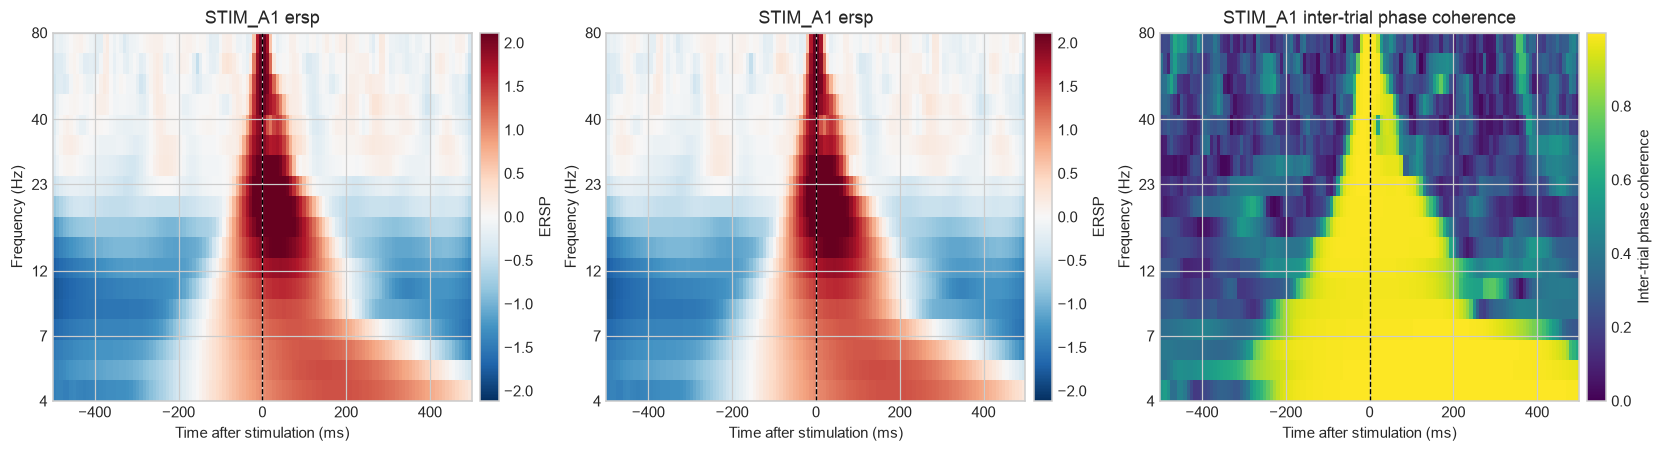

In [3]:
psd = ep.compute_psd(epochs, channels=epochs.channels[:4], fmin=2, fmax=100, nperseg=256)
ax = viz.plot_psd(psd, logx=False)
plt.show()

tfr = ep.compute_tfr(epochs, "STIM_A1", config=config)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
viz.plot_tfr(tfr, ax=axes[0])
viz.plot_ersp(tfr, ax=axes[1])
itpc = ep.inter_trial_phase_coherence(epochs, "STIM_A1", config=config)
viz.plot_itpc(itpc, ax=axes[2])
plt.show()

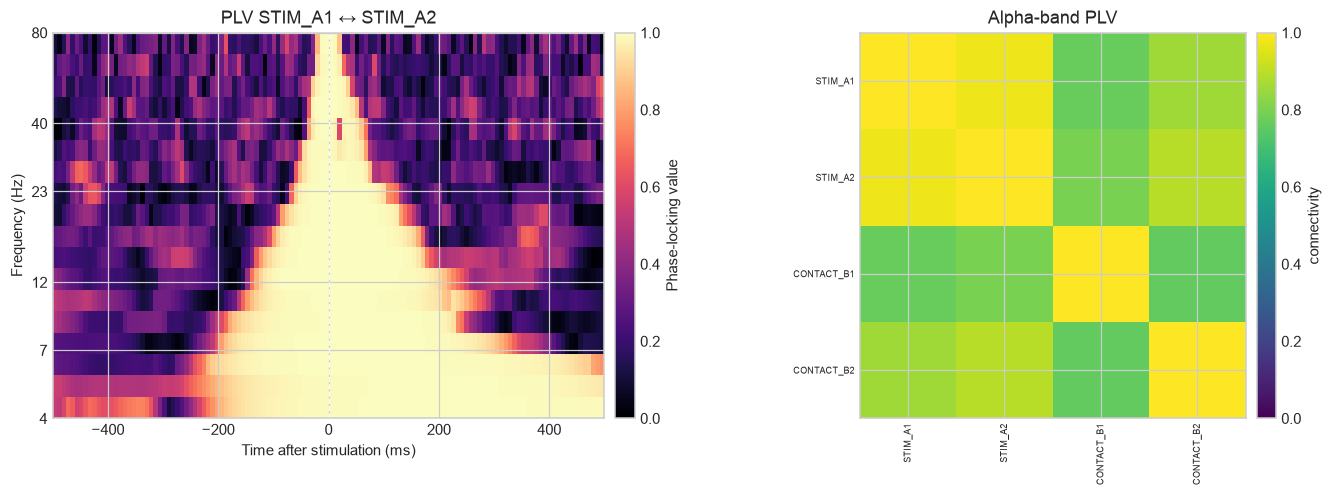

In [4]:
plv_tf = ep.phase_locking_value(epochs, "STIM_A1", "STIM_A2", config=config)
plv = ep.plv_matrix(epochs, band=(8, 13), channels=epochs.channels[:4], time_window=(0.01, 0.25))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), layout="constrained")
viz.plot_plv_timefreq(plv_tf, ax=axes[0])
viz.plot_connectivity_matrix(plv, ax=axes[1], title="Alpha-band PLV")
plt.show()

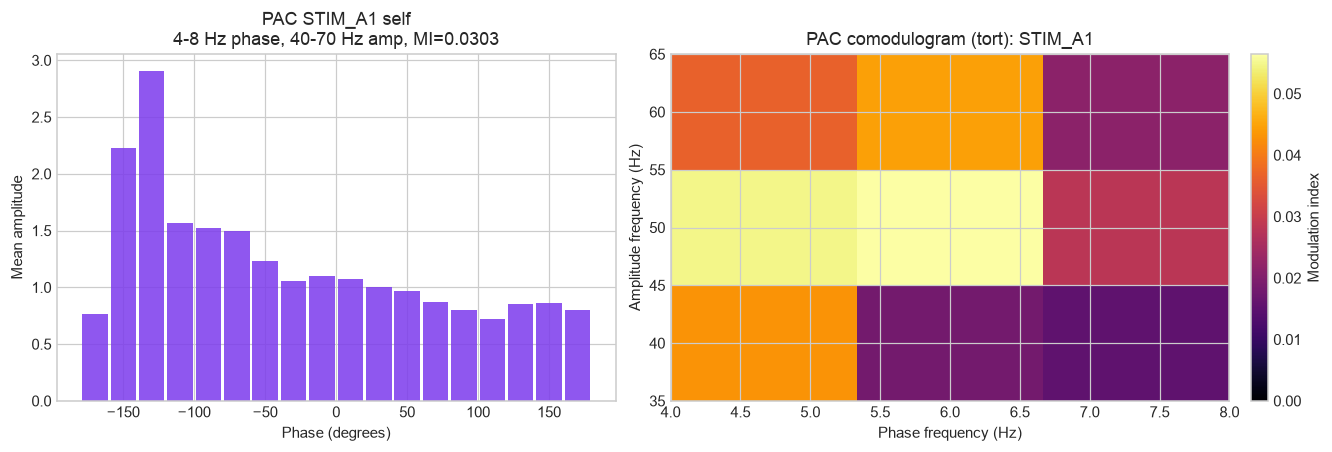

In [5]:
pac = ep.phase_amplitude_coupling(
    epochs, "STIM_A1", "STIM_A1", phase_band=(4, 8), amp_band=(40, 70),
    time_window=(0.02, 0.30)
)
comod = ep.phase_amplitude_comodulogram(
    epochs, "STIM_A1", phase_freqs=[4, 6, 8], amp_freqs=[35, 50, 65],
    bandwidth_phase=2, bandwidth_amp=14, time_window=(0.02, 0.30)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
viz.plot_pac(pac, ax=axes[0])
viz.plot_comodulogram(comod, ax=axes[1])
plt.show()

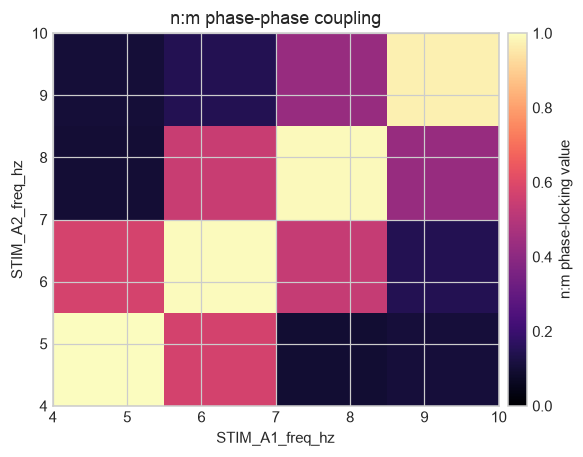

EpochsSpectral SpectralPlotter


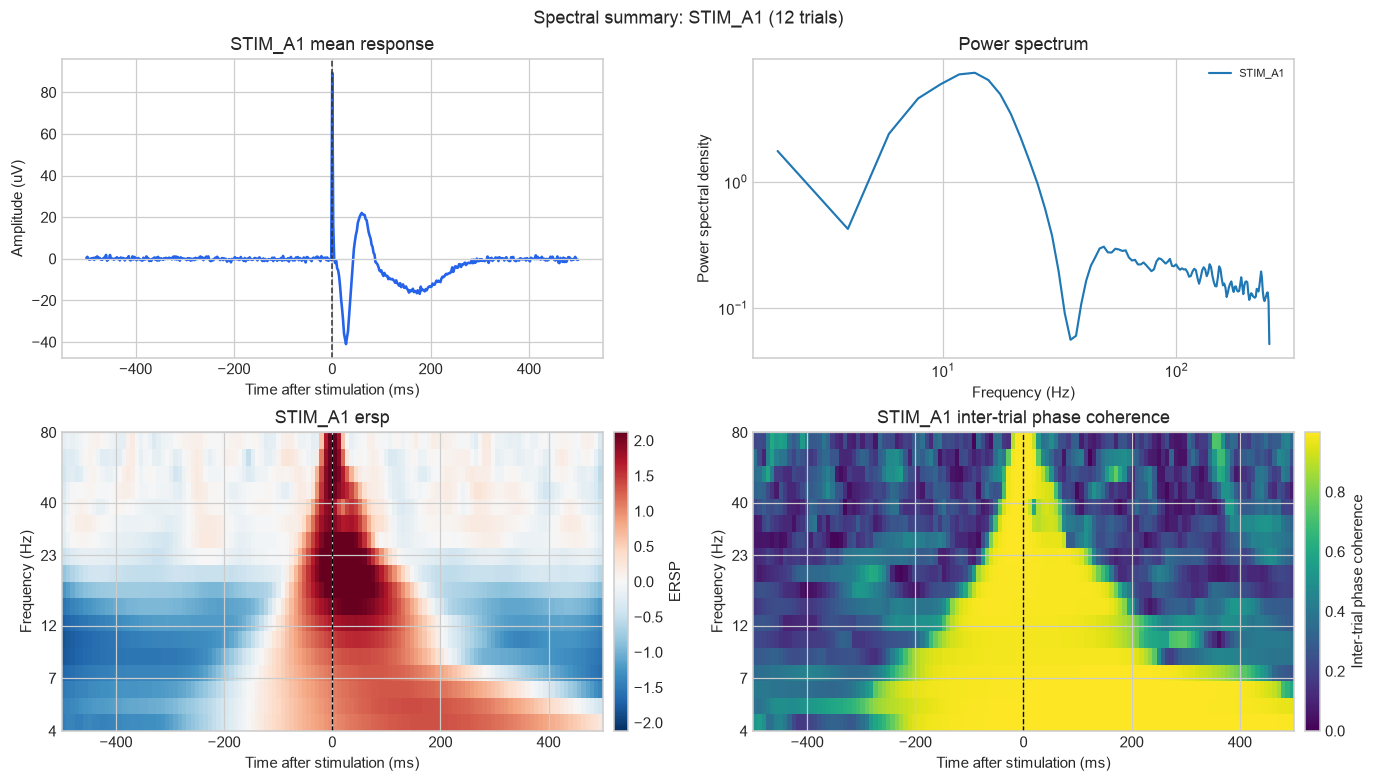

In [6]:
phase_matrix = ep.phase_phase_matrix(
    epochs, "STIM_A1", "STIM_A2", freqs_x=[4, 6, 8, 10],
    freqs_y=[4, 6, 8, 10], time_window=(0.02, 0.30)
)
ax = viz.plot_phase_phase_matrix(phase_matrix)
plt.show()

# The accessor exposes the same calculations and plotting family.
accessor = epochs.spectral
print(type(accessor).__name__, type(accessor.plot).__name__)

fig = viz.plot_spectral_summary(epochs, "STIM_A1", config=config)
plt.show()